# Quality-guided paths: watch the frontier grow

Which already-reached neighbor should propose the next pixel’s phase?

We start with numbers that can be checked by hand, draw the algorithm’s decision, then run the public API on data with known truth. All phase values are in radians unless stated otherwise.

In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd().resolve()
if not (ROOT / 'src' / 'parvaneh').is_dir(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
import parvaneh as pv
plt.rcParams.update({'figure.dpi': 115, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
def W(x): return (np.asarray(x)+np.pi) % (2*np.pi)-np.pi
def table(headers, rows):
    display(Markdown('| '+' | '.join(headers)+' |\n|'+
        '|'.join(['---']*len(headers))+'|\n'+
        '\n'.join('| '+' | '.join(map(str,r))+' |' for r in rows)))
def images(arrays, titles, cmap='viridis'):
    fig,axes=plt.subplots(1,len(arrays),figsize=(4*len(arrays),3.4),constrained_layout=True)
    for ax,a,title in zip(np.atleast_1d(axes),arrays,titles):
        im=ax.imshow(a,cmap=cmap); ax.set(title=title,xlabel='column',ylabel='row')
        fig.colorbar(im,ax=ax,shrink=.75)
    plt.show()
def align(u,t): return u-np.mean(u-t)
def scene():
    y,x=np.mgrid[0:18,0:22]
    truth=.38*x+.22*y+1.4*np.exp(-((x-12)**2+(y-8)**2)/25)
    patch=(x>=8)&(x<=14)&(y>=5)&(y<=12)
    rng=np.random.default_rng(21)
    phase=W(truth+rng.normal(size=truth.shape)*np.where(patch,1.35,.06))
    confidence=np.where(patch,.2,1.)
    return truth,phase,confidence
def report(u,t,w):
    assert u.shape==t.shape and np.isfinite(u).all()
    table(['Quantity','Measured value'],[
        ['Aligned RMSE (rad)',f'{pv.rmse_aligned(u,t):.6f}'],
        ['Raw max wrapped difference from input (rad)',f'{np.max(np.abs(W(u-w))):.6f}']])
    images([align(u,t),align(u,t)-t],['Aligned reconstruction (rad)','Error against truth (rad)'])

## 1 · Work through the model

On an accepted parent $a$ and candidate $b$, propose
$u_b=u_a+W(w_b-w_a)$. Rank candidates by their quality; accept the best queued
candidate, then propose its still-unseen neighbors. The accepted phase is frozen.

1. Seed a valid region. In this implementation the first seed is the first
   unvisited valid pixel in array order, not the globally best-quality pixel.
2. Queue neighbors with their parent and quality.
3. Accept the highest-priority queued candidate.
4. Continue; restart if another disconnected region remains.

For $u_a=2.8$ and $w_b=-2.9$, the raw difference is $-5.7$ but its principal
step is about $0.583$, so the proposed $u_b$ is about $3.383$ radians.

| Quantity | Radians |
|---|---|
| Raw difference | -5.699999999999999 |
| Wrapped difference | 0.5831853071795869 |
| Proposal | 3.3831853071795868 |

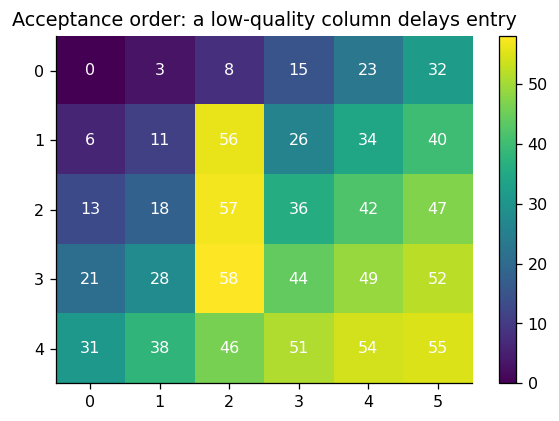

In [2]:
parent=2.8; child=-2.9; step=float(W(child-parent))
table(['Quantity','Radians'],[['Raw difference',child-parent],['Wrapped difference',step],['Proposal',parent+step]])
y,x=np.mgrid[0:5,0:6]; tiny=W(.8*x+.5*y)
quality=np.ones_like(tiny); quality[1:4,2]=.05
tiny_u,order=pv.quality_guided_unwrap(tiny,quality,return_order=True)
fig,ax=plt.subplots(figsize=(6,4)); im=ax.imshow(order,cmap='viridis')
for r,c in np.ndindex(order.shape): ax.text(c,r,str(order[r,c]),ha='center',va='center',color='white')
ax.set_title('Acceptance order: a low-quality column delays entry'); plt.colorbar(im,ax=ax); plt.show()
assert np.allclose(W(tiny_u-tiny),0)

## 2 · Read the calculation

The low-quality strip remains valid; it is delayed rather than removed. A poor
early parent decision can affect descendants. This is a frontier algorithm,
not the global edge sorting used by `reliability_unwrap`. The default quality
map and the string mode `quality='min_gradient'` also use different priorities.

## 3 · Run the implementation

The seed and input sizes below are fixed. A low objective or a converged solver means the chosen mathematical problem was solved; it does not prove the physical phase was recovered.

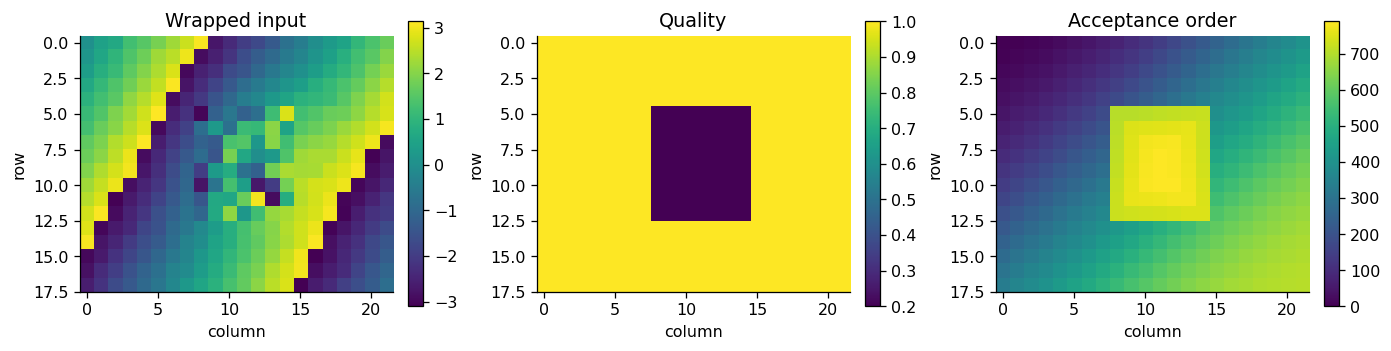

| Quantity | Measured value |
|---|---|
| Aligned RMSE (rad) | 0.473078 |
| Raw max wrapped difference from input (rad) | 0.000000 |

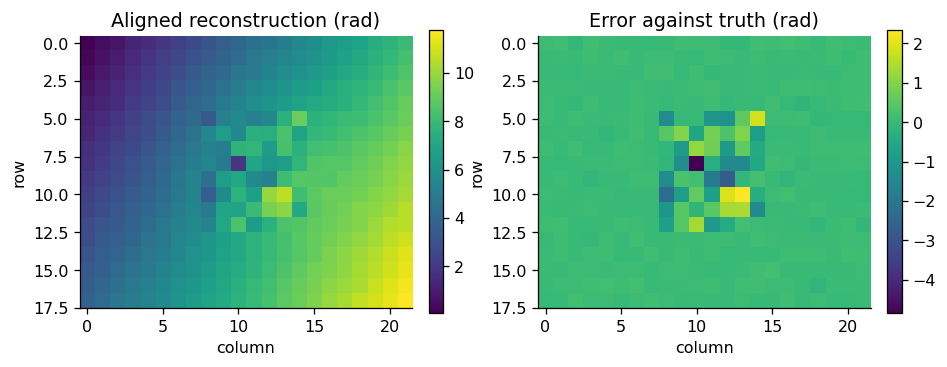

In [3]:
truth,phase,confidence=scene()
u,order=pv.quality_guided_unwrap(phase,confidence,return_order=True)
images([phase,confidence,order],['Wrapped input','Quality','Acceptance order'])
report(u,truth,phase)

## 4 · Change one choice and measure its effect

This controlled experiment changes a solver setting, data condition, or reference calculation. Compare the measured values before drawing a conclusion.

In [4]:
scores=[]
for label,q in [('Supplied',confidence),('Default',None),('Min gradient','min_gradient')]:
    u=pv.quality_guided_unwrap(phase,q)
    scores.append([label,f'{pv.rmse_aligned(u,truth):.4f}',f'{np.max(np.abs(W(u-phase))):.4f}'])
table(['Priority','Aligned RMSE','Raw wrapping error'],scores)

| Priority | Aligned RMSE | Raw wrapping error |
|---|---|---|
| Supplied | 0.4731 | 0.0000 |
| Default | 0.4115 | 0.0000 |
| Min gradient | 0.5116 | 3.1416 |

## 5 · Interpretation and limits

Only 2-D input is supported. `return_order` exposes traversal, not uncertainty.
The bounded frontier can postpone candidates; ties and `max_frontier` affect
order. Masked pixels are NaN. The legacy `min_gradient` path uses float32 cycle
coordinates and a shifted phase origin, visible in the raw wrapping error.
Mean-aligned RMSE removes a constant offset but does not certify absolute phase.

## Continue exploring

Rerun with another seed or a larger phase step. Predict which assumption fails first, then inspect the result and report. The method’s output convention and masks matter as much as its RMSE.

Implementation: [`path_following.py`](../src/parvaneh/path_following.py). See the [API reference](../docs/api.md), [notebook index](../docs/notebooks.md), [mathematical derivations](../docs/mathematics.md), and [bibliography](../docs/references.md) for further reading. These examples describe the current implementation, including its limitations; they are not claims of numerical identity with external software.